In [9]:
#Librerias
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
#Conexion con drive


ruta = r"\\wsl.localhost\Ubuntu\home\luisr\tls-project"

In [11]:
#Datos de implementacion en LINUX
df_tls13 = pd.read_csv(ruta + "/dataset_tls.csv")
df_tls12 = pd.read_csv(ruta + "/dataset_tls_1_2.csv")

#Preparación de los datos linux


In [12]:
#Agregamos las columnas con el protocolo y  el sistema donde se opero

df_tls13["Sistema"] = "Linux"
df_tls13["Protocolo"] = "TLS1.3"
df_tls12["Sistema"] = "Linux"
df_tls12["Protocolo"] = "TLS1.2"

In [13]:
# Unimos los csv en un gran DataFrame para cada sistema operativo
df = pd.concat([df_tls13, df_tls12], ignore_index=True)



#Limpieza LINUX
df = df[df["status"] == "OK"]
df = df.dropna()


In [14]:
columnas = ["time_connect", "time_appconnect", "time_total"]

# Procesar Linux
for col in columnas:
    if col in df.columns:
        df[col] = df[col] * 1000

df = df.rename(columns={
    "time_connect": "time_connect_ms",
    "time_appconnect": "time_appconnect_ms",
    "time_total": "time_total_ms"
})


In [15]:
# 1. Definimos las columnas que queremos que existan en AMBOS
columnas_tiempo = ["time_connect", "time_appconnect", "time_total", "handshake_ms"]

# --- PROCESAR LINUX ---
for col in columnas_tiempo:
    if col in df.columns:
        # Si el promedio es menor a 10, es que está en SEGUNDOS (ej: 0.15) -> multiplicamos
        if df[col].mean() < 10:
            df[col] = df[col] * 1000
    else:
        # Si la columna no existe en Linux, la creamos vacía para que coincida con Mac
        df[col] = pd.NA


# 2. Renombrar todas para que terminen en _ms y sean idénticas
rename_map = {c: f"{c}_ms" if not c.endswith("_ms") else c for c in columnas_tiempo}

df = df.rename(columns=rename_map)


In [16]:
#Dataframe de cada variable individual

#Latencia
df_lat = df[df["Variable"] == "Latencia"].copy()
df_lat["Valor"] = pd.to_numeric(df_lat["Valor"], errors="coerce")
df_lat = df_lat.sort_values(by="Valor")

#Perdida
df_perd = df[df["Variable"] == "Perdida"].copy()
df_perd["Valor"] = pd.to_numeric(df_perd["Valor"], errors="coerce")
df_perd = df_perd.sort_values(by="Valor")

#Jitter
df_jit = df[df["Variable"] == "Jitter"].copy()
df_jit["Valor"] = pd.to_numeric(df_jit["Valor"], errors="coerce")
df_jit = df_jit.sort_values(by="Valor")

#Mac



In [17]:
#Dataframe para los escenarios

#Servidor internacional
df_serv = df[df["Variable"] == "Servidor_Internacional"].copy()
df_serv["Valor"] = pd.to_numeric(df_serv["Valor"], errors="coerce")
df_serv = df_serv.sort_values(by="Valor")




#WiFi_Publico
df_wifi = df[df["Variable"] == "WiFi_Publico"].copy()
df_wifi["Valor"] = pd.to_numeric(df_wifi["Valor"], errors="coerce")
df_wifi = df_wifi.sort_values(by="Valor")



#Datos_Moviles
df_mov = df[df["Variable"] == "Datos_Moviles"].copy()
df_mov["Valor"] = pd.to_numeric(df_mov["Valor"], errors="coerce")
df_mov = df_mov.sort_values(by="Valor")



#Red_Degrada
df_red = df[df["Variable"] == "Red_Degradada"].copy()
df_red["Valor"] = pd.to_numeric(df_red["Valor"], errors="coerce")
df_red = df_red.sort_values(by="Valor")







##Metricas de evaluacion

In [18]:
#Promedio de las iteraciones para cada parametro
prom_lat = df_lat.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()
prom_perd = df_perd.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()
prom_jit = df_jit.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()

##Graficas

###Grafica de promedios (Rregresion)

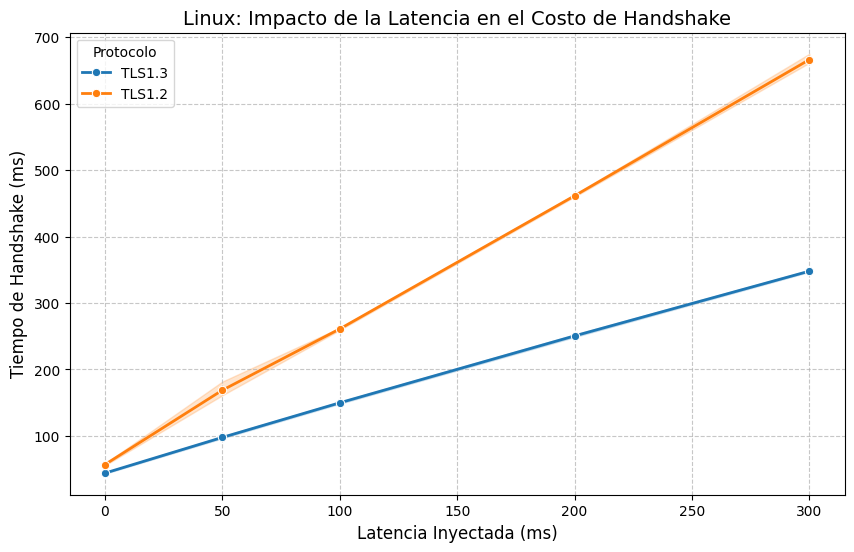

In [19]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_lat, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2)

plt.title('Linux: Impacto de la Latencia en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

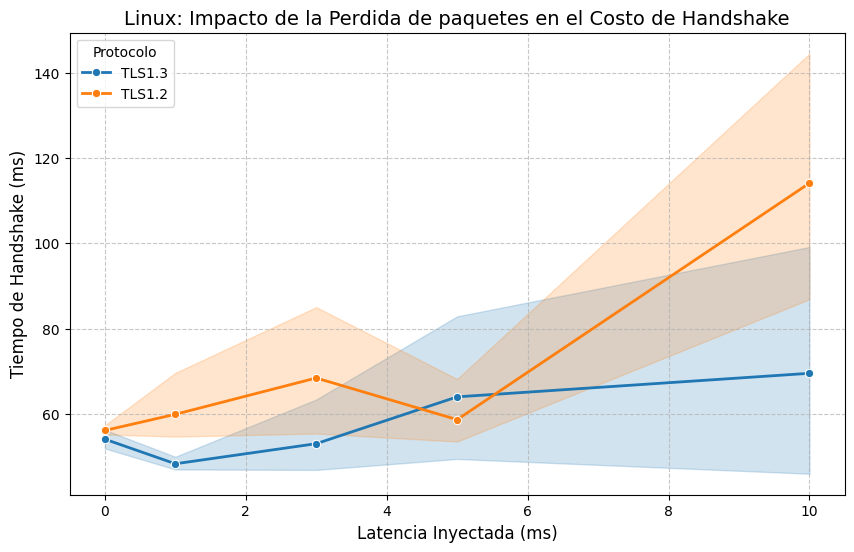

In [20]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_perd, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2)

plt.title('Linux: Impacto de la Perdida de paquetes en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

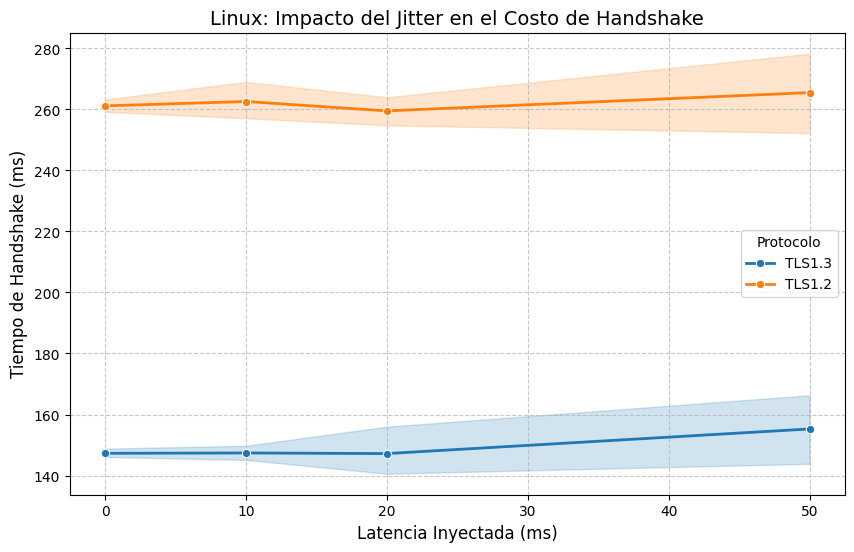

In [21]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_jit, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2)

plt.title('Linux: Impacto del Jitter en el Costo de Handshake', fontsize=14)
plt.xlabel('Latencia Inyectada (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

### Graica de datos (Dispersión)

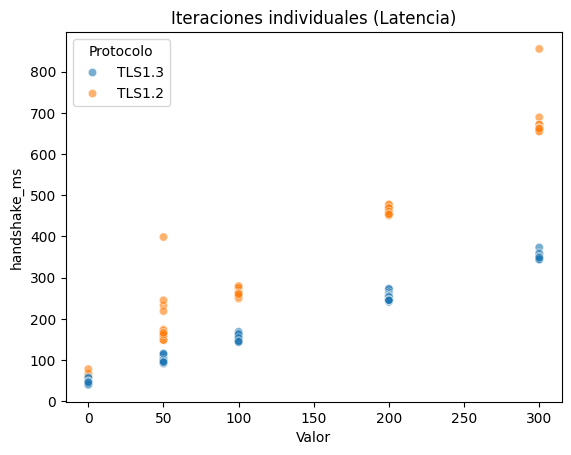

In [22]:
sns.scatterplot(data=df_lat, x="Valor", y="handshake_ms", hue="Protocolo", alpha=0.6)

plt.title("Iteraciones individuales (Latencia)")
plt.show()

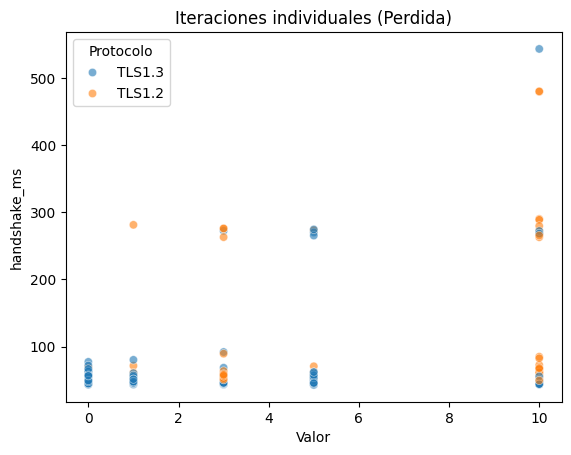

In [23]:
sns.scatterplot(data=df_perd, x="Valor", y="handshake_ms", hue="Protocolo", alpha=0.6)

plt.title("Iteraciones individuales (Perdida)")
plt.show()

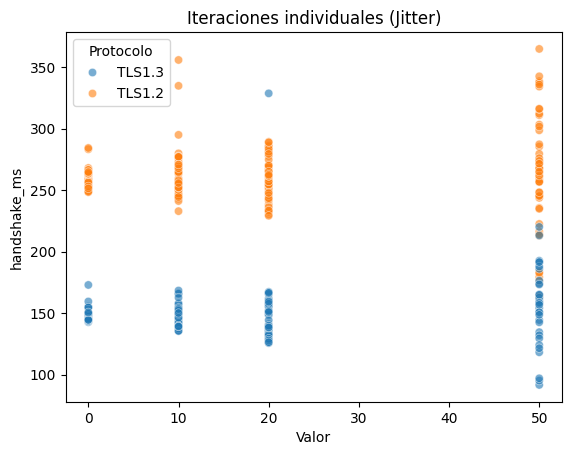

In [24]:
sns.scatterplot(data=df_jit, x="Valor", y="handshake_ms", hue="Protocolo", alpha=0.6)

plt.title("Iteraciones individuales (Jitter)")
plt.show()

### Graficas de diferencias

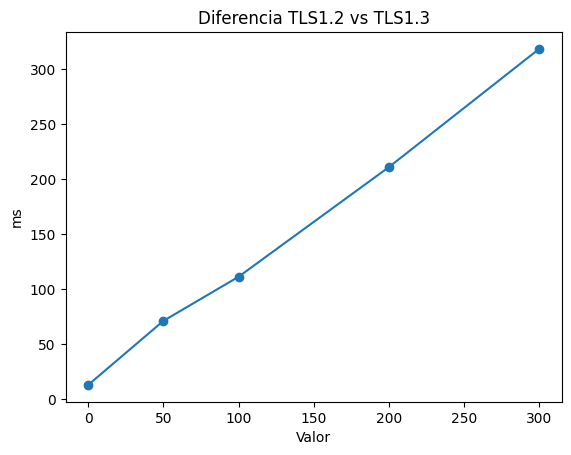

In [25]:
df_diff = df_lat.groupby(["Valor","Protocolo"])["handshake_ms"].mean().unstack()

df_diff["Diferencia"] = df_diff["TLS1.2"] - df_diff["TLS1.3"]

df_diff["Diferencia"].plot(marker="o")
plt.title("Diferencia TLS1.2 vs TLS1.3")
plt.ylabel("ms")
plt.show()
